In [25]:
import pandas as pd

df_sample = pd.read_csv('medicare_prescriber.csv', nrows=200000)
df_sample.to_csv('upload_me.csv', index=False)

In [14]:
%pip install snowflake-connector-python pandas seaborn matplotlib

Note: you may need to restart the kernel to use updated packages.


In [19]:
import snowflake.connector
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

conn = snowflake.connector.connect(
    user='YOUR_USERNAME',          
    password='YOUR_PASSWORD',      
    account='YOUR_ACCOUNT_ID',     
    warehouse='COMPUTE_WH',
    database='MEDICARE_DB',
    schema='PUBLIC')

In [23]:
query = """
WITH Opioid_Data AS (
    SELECT 
        PRSCRBR_NPI,
        PRSCRBR_LAST_ORG_NAME,
        PRSCRBR_TYPE as Specialty,
        TOT_CLMS
    FROM RAW_PRESCRIBER_DATA
    WHERE 
        -- Feature Engineering: Find drugs by text pattern
        BRND_NAME ILIKE '%OXYCODONE%' 
        OR BRND_NAME ILIKE '%HYDROCODONE%' 
        OR BRND_NAME ILIKE '%FENTANYL%' 
        OR BRND_NAME ILIKE '%MORPHINE%'
        OR BRND_NAME ILIKE '%OXYCONTIN%'
        OR BRND_NAME ILIKE '%TRAMADOL%'
),
Benchmarks AS (
    SELECT 
        *,
        AVG(TOT_CLMS) OVER (PARTITION BY Specialty) as Specialty_Avg,
        STDDEV(TOT_CLMS) OVER (PARTITION BY Specialty) as Specialty_StdDev
    FROM Opioid_Data
)
SELECT 
    *,
    (TOT_CLMS - Specialty_Avg) / NULLIF(Specialty_StdDev, 0) as Z_Score
FROM Benchmarks
WHERE Z_Score IS NOT NULL
ORDER BY Z_Score DESC;
"""

/var/folders/c_/bzllg5tx7hz0jwt4lpvg7b380000gn/T/ipykernel_14565/3492954976.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


✅ Analysis Complete! Retrieved 5891 records.


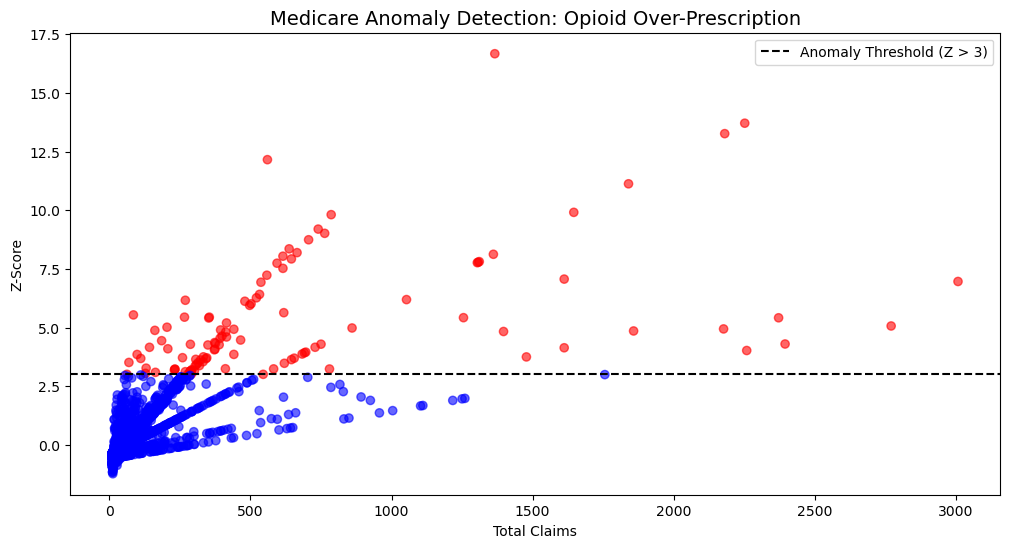

,PRSCRBR_NPI,PRSCRBR_LAST_ORG_NAME,SPECIALTY,TOT_CLMS,SPECIALTY_AVG,SPECIALTY_STDDEV,Z_SCORE
0,1003816372,Moore,Internal Medicine,1366,53.040,78.745765,16.673405
1,1003406653,Keesee,Nurse Practitioner,2252,65.985,159.429002,13.711527
2,1003302639,Parish,Nurse Practitioner,2181,65.985,159.429002,13.266187
3,1003848706,Riehl,Emergency Medicine,560,27.730,43.783551,12.156849
4,1003486556,Johnston,Nurse Practitioner,1840,65.985,159.429002,11.127304


In [24]:
df = pd.read_sql(query, conn)
print(f"✅ Analysis Complete! Retrieved {len(df)} records.")

# Clean columns
df.columns = [col.upper() for col in df.columns]

# Plot
plt.figure(figsize=(12, 6))
colors = df['Z_SCORE'].apply(lambda x: 'red' if x > 3 else 'blue')

plt.scatter(
    df['TOT_CLMS'], 
    df['Z_SCORE'], 
    c=colors, 
    alpha=0.6
)

plt.axhline(3, color='black', linestyle='--', label='Anomaly Threshold (Z > 3)')
plt.title('Medicare Anomaly Detection: Opioid Over-Prescription', fontsize=14)
plt.xlabel('Total Claims')
plt.ylabel('Z-Score')
plt.legend()
plt.show()

# Top Risky Doctors
display(df[df['Z_SCORE'] > 3].head(5))